# 02 — Exploratory Data Analysis and Featurization

This notebook loads the cleaned 45S5 bioactive glass scaffold dataset, examines distributions and relationships among variables, evaluates fabrication-group structure, and prepares physically meaningful features for regression modeling.

In [1]:
## 1. Imports and Data Loading
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✓ Imports successful")
print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")

✓ Imports successful
NumPy version: 2.4.6
pandas version: 3.0.3


In [2]:
## 2. Define Paths and Load the Cleaned Dataset
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_ROOT / "data"

CLEAN_DATA_PATH = DATA_DIR / "scaffold_data_clean.csv"

scaffold_data = pd.read_csv(CLEAN_DATA_PATH)

print("✓ Cleaned dataset loaded successfully")
print(f"Dataset shape: {scaffold_data.shape}")
print(f"Source file exists: {CLEAN_DATA_PATH.exists()}")

display(scaffold_data.head())

✓ Cleaned dataset loaded successfully
Dataset shape: (256, 19)
Source file exists: True


,Sample ID,Group ID,Size,Date Tested,Binder Composition,Feed Mix (g Bioglass : g PEG6000),Particle Size (microns),Sintering Temperature (°C),Sintering Time (hours),Final Volume (cm^3),Final Mass (g),Volume Loss (cm^3),Volume Loss (%),Mass Loss (g),Mass Loss (%),Compressive Load (N),Cross-Sectional Area (mm^2),Maximum Stress (MPa),Porosity (%)
0,1,4225:G1<90um,Evans 6mm,2025-04-22,PVA,100:20,<90,930,6,2.02,2.861,-0.30,-12.931034,-0.749,-20.747922,1819.25,169.0,10.764793,47.49
1,2,4225:G1<90um,Evans 6mm,2025-04-22,PVA,100:20,<90,930,6,2.03,2.901,-0.32,-13.617021,-0.769,-20.953678,1930.66,169.0,11.424024,47.05
2,3,4225:G1<90um,Evans 6mm,2025-04-22,PVA,100:20,<90,930,6,2.03,2.877,-0.33,-13.983051,-0.753,-20.743802,1650.06,169.0,9.763669,47.38
3,4,4225:G1<90um,Evans 6mm,2025-04-22,PVA,100:20,<90,930,6,2.03,2.868,-0.34,-14.345992,-0.752,-20.773481,1592.20,169.0,9.421302,47.61
4,5,4225:G1<90um,Evans 6mm,2025-04-22,PVA,100:20,<90,930,6,2.03,2.864,-0.32,-13.617021,-0.756,-20.883978,1570.20,169.0,9.291124,47.84


In [3]:
## 3. Inspect Dataset Structure
print("Dataset information:\n")
scaffold_data.info()

print("\nUnique values in categorical columns:")
categorical_columns = [
    "Group ID",
    "Size",
    "Binder Composition",
    "Feed Mix (g Bioglass : g PEG6000)",
    "Particle Size (microns)"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(scaffold_data[column].value_counts(dropna=False))

Dataset information:

<class 'pandas.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Sample ID                          256 non-null    int64  
 1   Group ID                           256 non-null    str    
 2   Size                               256 non-null    str    
 3   Date Tested                        256 non-null    str    
 4   Binder Composition                 256 non-null    str    
 5   Feed Mix (g Bioglass : g PEG6000)  256 non-null    str    
 6   Particle Size (microns)            256 non-null    str    
 7   Sintering Temperature (°C)         256 non-null    int64  
 8   Sintering Time (hours)             256 non-null    int64  
 9   Final Volume (cm^3)                256 non-null    float64
 10  Final Mass (g)                     256 non-null    float64
 11  Volume Loss (cm^3)                 256 non-null

In [4]:
## 4. Inspect Numeric Feature Variation
numeric_summary = scaffold_data.describe().T

numeric_summary["Unique Values"] = [
    scaffold_data[column].nunique()
    for column in numeric_summary.index
]

print("✓ Numeric summary created")
display(numeric_summary)

✓ Numeric summary created


,count,mean,std,min,25%,50%,75%,max,Unique Values
Sample ID,256.0,128.500000,74.045031,1.000000,64.750000,128.500000,192.250000,256.000000,256
Sintering Temperature (°C),256.0,930.000000,0.000000,930.000000,930.000000,930.000000,930.000000,930.000000,1
Sintering Time (hours),256.0,6.000000,0.000000,6.000000,6.000000,6.000000,6.000000,6.000000,1
Final Volume (cm^3),256.0,3.226181,0.775130,1.216380,3.283599,3.495000,3.652500,4.068544,164
Final Mass (g),256.0,4.269461,0.983347,1.808000,3.946500,4.611000,4.933500,5.572000,212
Volume Loss (cm^3),256.0,-0.429072,0.156918,-0.730000,-0.550000,-0.449535,-0.331238,0.070474,197
Volume Loss (%),256.0,-10.165169,3.241642,-17.298578,-12.447387,-10.149185,-8.882653,5.596663,224
Mass Loss (g),256.0,-1.339344,0.574362,-2.929000,-1.703000,-1.332500,-0.760500,-0.371000,216
Mass Loss (%),256.0,-23.541882,7.620929,-48.719228,-27.935764,-21.599394,-20.758779,-6.429809,225
Compressive Load (N),256.0,3662.831449,2676.187185,472.830000,1414.617500,2533.000000,5650.747500,9954.780000,220


In [5]:
## 5. Identify Constant and Non-Predictive 
constant_columns = [
    column
    for column in scaffold_data.columns
    if scaffold_data[column].nunique(dropna=False) == 1
]

identifier_columns = [
    "Sample ID",
    "Group ID",
    "Date Tested"
]

print("Constant columns:")
for column in constant_columns:
    print(f"  - {column}")

print("\nIdentifier or grouping columns:")
for column in identifier_columns:
    print(f"  - {column}")

Constant columns:
  - Particle Size (microns)
  - Sintering Temperature (°C)
  - Sintering Time (hours)

Identifier or grouping columns:
  - Sample ID
  - Group ID
  - Date Tested


Target summary:
count    256.000000
mean      22.577147
std       17.134958
min        2.637052
25%        8.815910
50%       13.864833
75%       37.013569
max       67.907935
Name: Maximum Stress (MPa), dtype: float64


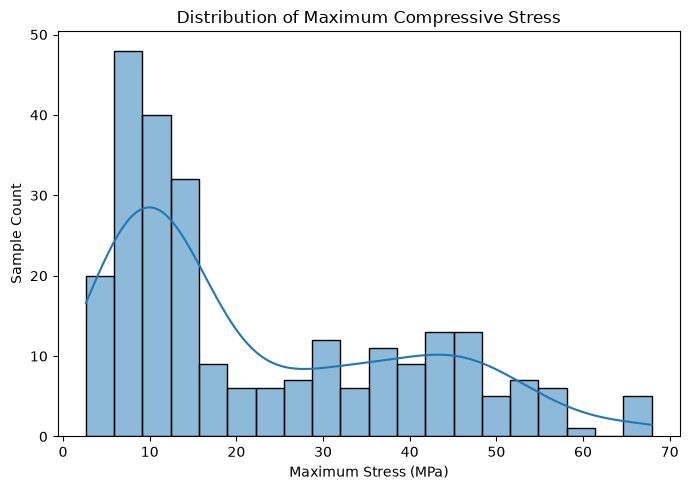

In [6]:
## 6. Examine the Target Distribution
TARGET_COLUMN = "Maximum Stress (MPa)"

target_summary = scaffold_data[TARGET_COLUMN].describe()

print("Target summary:")
print(target_summary)

plt.figure(figsize=(7, 5))
sns.histplot(
    data=scaffold_data,
    x=TARGET_COLUMN,
    bins=20,
    kde=True
)
plt.title("Distribution of Maximum Compressive Stress")
plt.xlabel("Maximum Stress (MPa)")
plt.ylabel("Sample Count")
plt.tight_layout()
plt.show()

Pearson correlation between porosity and maximum stress: -0.007


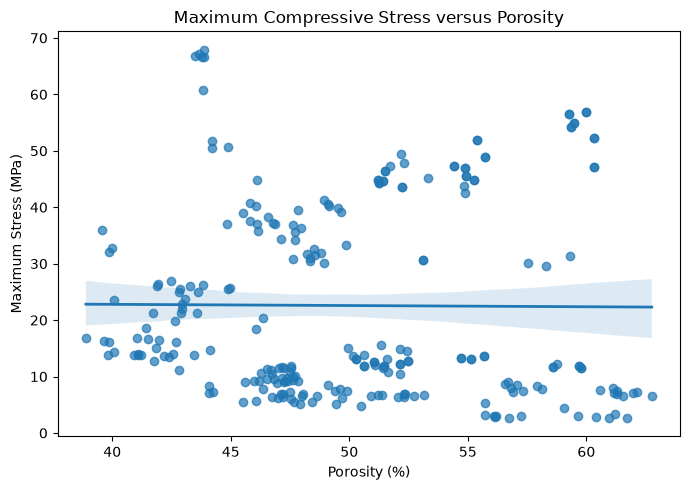

In [7]:
## 7. Examine the Porosity–Strength Relationship
porosity_strength_correlation = scaffold_data[
    ["Porosity (%)", "Maximum Stress (MPa)"]
].corr().iloc[0, 1]

print(
    f"Pearson correlation between porosity and maximum stress: "
    f"{porosity_strength_correlation:.3f}"
)

plt.figure(figsize=(7, 5))
sns.regplot(
    data=scaffold_data,
    x="Porosity (%)",
    y="Maximum Stress (MPa)",
    scatter_kws={"alpha": 0.7},
    line_kws={"linewidth": 2}
)

plt.title("Maximum Compressive Stress versus Porosity")
plt.xlabel("Porosity (%)")
plt.ylabel("Maximum Stress (MPa)")
plt.tight_layout()
plt.show()

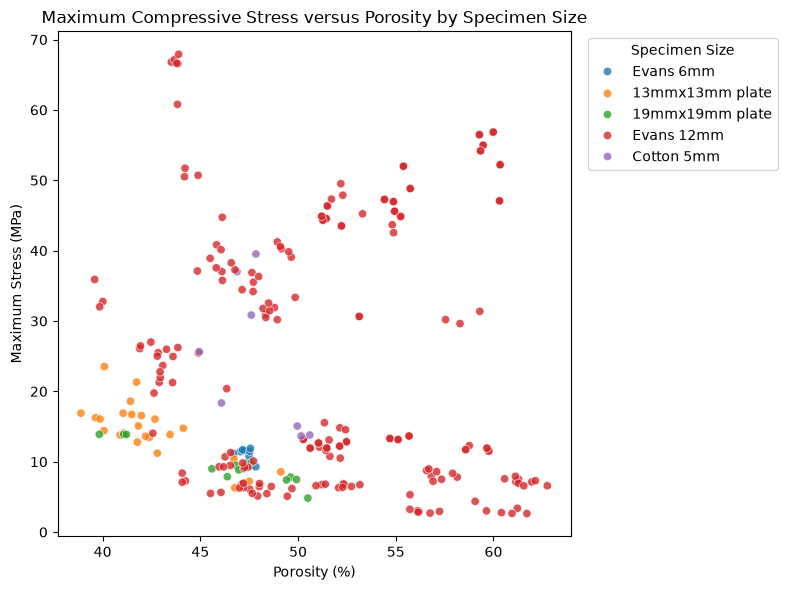

In [8]:
## 8. Porosity–Strength Relationship by Specimen Size
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=scaffold_data,
    x="Porosity (%)",
    y="Maximum Stress (MPa)",
    hue="Size",
    alpha=0.8
)

plt.title("Maximum Compressive Stress versus Porosity by Specimen Size")
plt.xlabel("Porosity (%)")
plt.ylabel("Maximum Stress (MPa)")
plt.legend(title="Specimen Size", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [9]:
## 9. Porosity–Strength Correlation by Specimen Size
size_correlation_summary = (
    scaffold_data
    .groupby("Size")
    .apply(
        lambda group: pd.Series({
            "Sample Count": len(group),
            "Porosity–Strength Correlation": group[
                ["Porosity (%)", "Maximum Stress (MPa)"]
            ].corr().iloc[0, 1]
        }),
        include_groups=False
    )
    .sort_values("Sample Count", ascending=False)
)

print("✓ Correlations calculated by specimen size")
display(size_correlation_summary)

✓ Correlations calculated by specimen size


,Sample Count,Porosity–Strength Correlation
Size,,
Evans 12mm,202.0,-0.133122
13mmx13mm plate,24.0,-0.756497
19mmx19mm plate,12.0,-0.947008
Evans 6mm,10.0,-0.497277
Cotton 5mm,8.0,-0.526795


✓ Strength summary calculated by binder composition


,count,mean,median,std,min,max
Binder Composition,,,,,,
PVA,173,22.05,13.86,16.08,4.83,56.85
PVA Glycerol,21,4.58,3.38,1.86,2.64,6.87
PVA PEG200,62,30.13,32.95,18.07,5.52,67.91


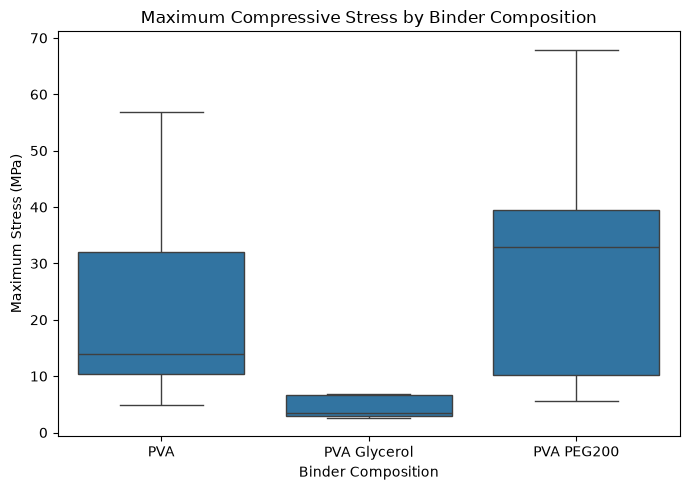

In [10]:
## 10. Strength Distribution by Binder Composition
binder_summary = (
    scaffold_data
    .groupby("Binder Composition")["Maximum Stress (MPa)"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

print("✓ Strength summary calculated by binder composition")
display(binder_summary)

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=scaffold_data,
    x="Binder Composition",
    y="Maximum Stress (MPa)"
)

plt.title("Maximum Compressive Stress by Binder Composition")
plt.xlabel("Binder Composition")
plt.ylabel("Maximum Stress (MPa)")
plt.tight_layout()
plt.show()

✓ Strength summary calculated by feed mix


,count,mean,median,std,min,max
Feed Mix (g Bioglass : g PEG6000),,,,,,
100:10,12,29.09,28.69,17.82,10.51,49.51
100:0,16,27.72,26.03,6.04,20.38,44.74
100:5,5,19.96,21.25,3.49,14.04,22.79
100:20,154,21.12,13.64,16.23,4.83,67.91
100:30,32,22.64,13.22,19.29,2.70,48.82
100:40,37,24.62,11.72,22.04,2.64,56.85


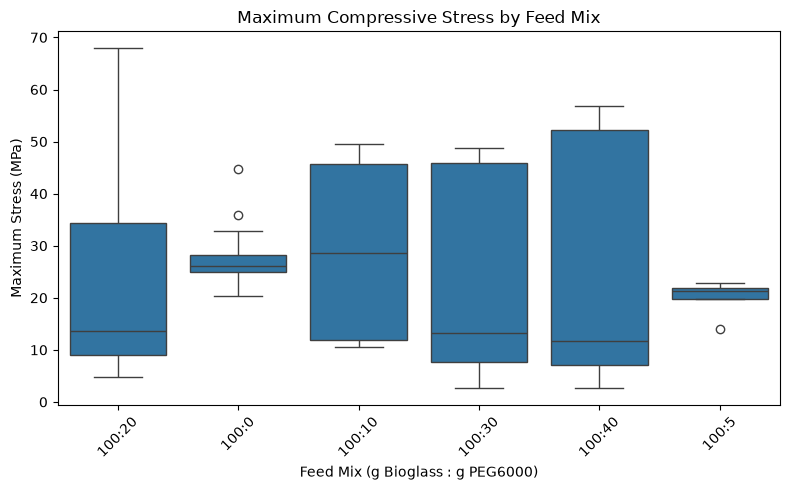

In [11]:
## 11. Strength Distribution by Feed Mix
feed_mix_summary = (
    scaffold_data
    .groupby("Feed Mix (g Bioglass : g PEG6000)")["Maximum Stress (MPa)"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
    .sort_values("median", ascending=False)
)

print("✓ Strength summary calculated by feed mix")
display(feed_mix_summary)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=scaffold_data,
    x="Feed Mix (g Bioglass : g PEG6000)",
    y="Maximum Stress (MPa)"
)

plt.title("Maximum Compressive Stress by Feed Mix")
plt.xlabel("Feed Mix (g Bioglass : g PEG6000)")
plt.ylabel("Maximum Stress (MPa)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

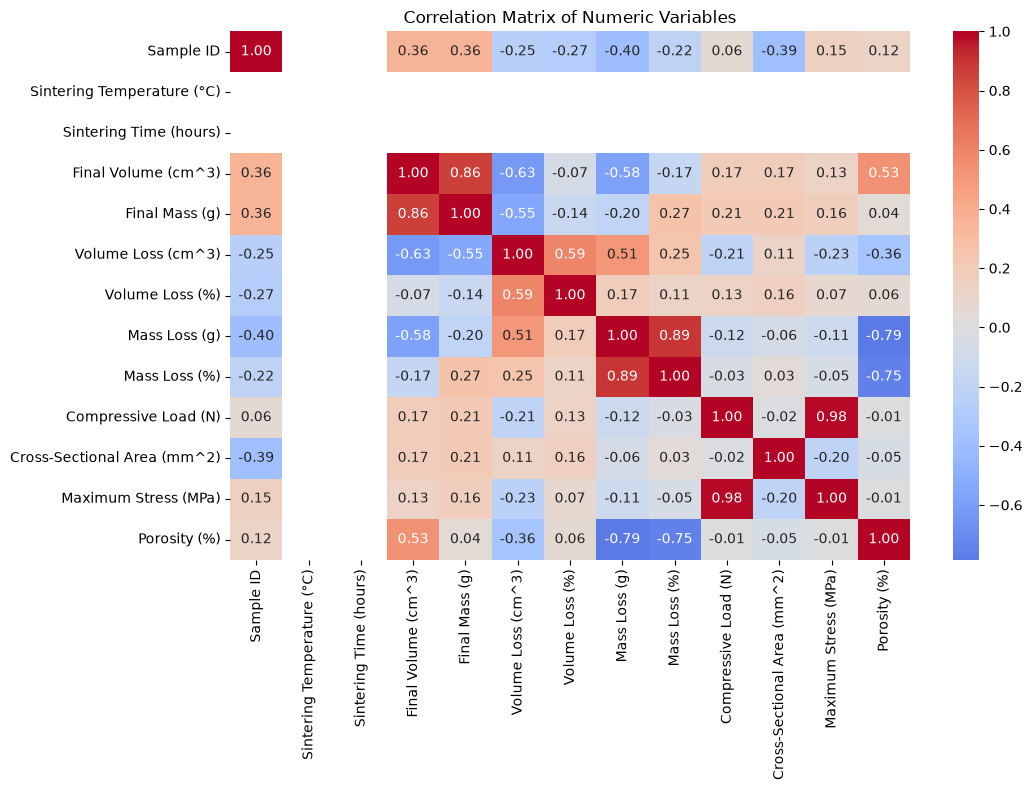

Important leakage warning:
- Maximum Stress (MPa) is calculated from Compressive Load (N) and Cross-Sectional Area (mm^2).
- Compressive Load (N) must not be used as a predictor because it contains direct information used to calculate the target.


In [12]:
## 12. Numeric Correlations and Leakage Review
numeric_columns = scaffold_data.select_dtypes(include="number").columns

correlation_matrix = scaffold_data[numeric_columns].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

print("Important leakage warning:")
print(
    "- Maximum Stress (MPa) is calculated from Compressive Load (N) "
    "and Cross-Sectional Area (mm^2)."
)
print(
    "- Compressive Load (N) must not be used as a predictor because it "
    "contains direct information used to calculate the target."
)

# Leakage Note
Maximum stress is calculated from compressive load divided by cross-sectional area. The strong correlation with load is therefore physically required. Compressive load is excluded from prediction because it directly determines the target. Cross-sectional area is retained only for a separate geometry-inclusive analysis.

In [13]:
## 13. Define Modeling Features and Exclude Leakage
TARGET_COLUMN = "Maximum Stress (MPa)"
GROUP_COLUMN = "Group ID"

excluded_predictor_columns = [
    "Sample ID",
    "Group ID",
    "Date Tested",
    "Particle Size (microns)",
    "Sintering Temperature (°C)",
    "Sintering Time (hours)",
    "Compressive Load (N)",
    "Maximum Stress (MPa)"
]

modeling_data = scaffold_data.drop(
    columns=excluded_predictor_columns
).copy()

target = scaffold_data[TARGET_COLUMN].copy()
groups = scaffold_data[GROUP_COLUMN].copy()

print("✓ Modeling feature table created")
print(f"Feature table shape: {modeling_data.shape}")
print(f"Target shape: {target.shape}")
print(f"Number of fabrication groups: {groups.nunique()}")

print("\nCandidate predictors:")
for column in modeling_data.columns:
    print(f"  - {column}")

✓ Modeling feature table created
Feature table shape: (256, 11)
Target shape: (256,)
Number of fabrication groups: 44

Candidate predictors:
  - Size
  - Binder Composition
  - Feed Mix (g Bioglass : g PEG6000)
  - Final Volume (cm^3)
  - Final Mass (g)
  - Volume Loss (cm^3)
  - Volume Loss (%)
  - Mass Loss (g)
  - Mass Loss (%)
  - Cross-Sectional Area (mm^2)
  - Porosity (%)


In [14]:
## 14. Separate Numeric and Categorical Features
categorical_features = modeling_data.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numeric_features = modeling_data.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical features:")
for feature in categorical_features:
    print(f"  - {feature}")

print("\nNumeric features:")
for feature in numeric_features:
    print(f"  - {feature}")

print(f"\nTotal categorical features: {len(categorical_features)}")
print(f"Total numeric features: {len(numeric_features)}")

Categorical features:
  - Size
  - Binder Composition
  - Feed Mix (g Bioglass : g PEG6000)

Numeric features:
  - Final Volume (cm^3)
  - Final Mass (g)
  - Volume Loss (cm^3)
  - Volume Loss (%)
  - Mass Loss (g)
  - Mass Loss (%)
  - Cross-Sectional Area (mm^2)
  - Porosity (%)

Total categorical features: 3
Total numeric features: 8


In [15]:
## 15. Define Main and Geometry-Inclusive Feature Sets

# Maximum stress is calculated from compressive load divided by cross-sectional area. Compressive load is therefore excluded because it directly determines the target.

# Cross-sectional area is excluded from the main materials/process model but retained in a separate geometry-inclusive feature set to test whether specimen geometry adds predictive value.

MAIN_EXCLUDED_COLUMNS = [
    "Sample ID",
    "Group ID",
    "Date Tested",
    "Particle Size (microns)",
    "Sintering Temperature (°C)",
    "Sintering Time (hours)",
    "Compressive Load (N)",
    "Cross-Sectional Area (mm^2)",
    "Maximum Stress (MPa)"
]

main_feature_data = scaffold_data.drop(
    columns=MAIN_EXCLUDED_COLUMNS
).copy()

geometry_feature_data = main_feature_data.copy()
geometry_feature_data["Cross-Sectional Area (mm^2)"] = scaffold_data[
    "Cross-Sectional Area (mm^2)"
]

target = scaffold_data["Maximum Stress (MPa)"].copy()
groups = scaffold_data["Group ID"].copy()

print("✓ Feature sets created")
print(f"Main feature set shape: {main_feature_data.shape}")
print(f"Geometry-inclusive feature set shape: {geometry_feature_data.shape}")
print(f"Target shape: {target.shape}")
print(f"Fabrication groups: {groups.nunique()}")

✓ Feature sets created
Main feature set shape: (256, 10)
Geometry-inclusive feature set shape: (256, 11)
Target shape: (256,)
Fabrication groups: 44


In [16]:
## 16. Save Analysis-Ready Feature Tables
MAIN_FEATURE_PATH = DATA_DIR / "main_features.csv"
GEOMETRY_FEATURE_PATH = DATA_DIR / "geometry_features.csv"
TARGET_GROUP_PATH = DATA_DIR / "target_and_groups.csv"

main_feature_data.to_csv(MAIN_FEATURE_PATH, index=False)
geometry_feature_data.to_csv(GEOMETRY_FEATURE_PATH, index=False)

target_and_groups = pd.DataFrame({
    "Maximum Stress (MPa)": target,
    "Group ID": groups
})
target_and_groups.to_csv(TARGET_GROUP_PATH, index=False)

print("✓ Analysis-ready files saved")
print(f"Main features: {MAIN_FEATURE_PATH.name}")
print(f"Geometry-inclusive features: {GEOMETRY_FEATURE_PATH.name}")
print(f"Target and groups: {TARGET_GROUP_PATH.name}")

✓ Analysis-ready files saved
Main features: main_features.csv
Geometry-inclusive features: geometry_features.csv
Target and groups: target_and_groups.csv


## 17. Notebook Summary

The cleaned scaffold dataset was explored for feature types, distributions, subgroup structure, correlations, and potential leakage.

Key findings:

- The dataset contains 256 samples across 44 fabrication groups.
- Particle size, sintering temperature, and sintering time are constant and provide no predictive variation.
- Maximum stress is strongly right-skewed.
- The overall porosity–strength correlation is near zero, but negative relationships appear within several specimen-size subgroups.
- Binder composition and feed mix are associated with substantial differences in strength.
- Compressive load was excluded because maximum stress is calculated directly from load and cross-sectional area.
- Separate main and geometry-inclusive feature tables were created for modeling.

The following files were saved for Notebook 3:

- `data/main_features.csv`
- `data/geometry_features.csv`
- `data/target_and_groups.csv`